# SPENVIS radiation-environment plots (generic, any number of missions)
## Author: D. Loveless, dlovele@iu.edu
## Date of last update: 2026-Sept-10
### This jupyter notebook generates plots of the near-Earth radiation environments (fluxes and fluences) reported from SPENVIS 
To be safe, create a custom kernel using the following:

`conda create -n radfx python=3.11 numpy pandas matplotlib jupyter ipykernel`
`conda activate radfx`
`python -m ipykernel install --user --name radfx --display-name "Python (radfx)"`

Then open the notebook and switch to the "Python (radfx)" kernel from the Kernel menu. Everything in that environment is built against one NumPy, and your main Anaconda install stays as it was.

All parsing/plotting lives in `spenvis_tools.py` (place in the same folder as this notebook).
To add or remove a mission, edit the `MISSIONS` dictionary below - nothing else changes.

Each mission is expected to have SPENVIS report files named `<prefix>_spenvis_<kind>.txt` in `DATA_DIR`:

| kind | contents |
|---|---|
| `tri` | trapped protons/electrons (AP-8 / AE-8, orbit-averaged flux) |
| `sefflare` | CREME-96 worst-day solar proton and ion flux |
| `sef` | ESP-PSYCHIC mission-total solar proton and ion fluence |
| `gcf` | CREME-96 galactic cosmic ray ion flux |

`<prefix>` can be any identifier you want. All files should be placed in the run directory `DATA_DIR`, along with `spenvis_tools.py`

Fluxes reported by SPENVIS in m⁻² are converted to cm⁻² automatically.

In [1]:
import matplotlib.pyplot as plt
from spenvis_tools import load_missions, plot_spectra, plot_all, threshold_table, summarize, ANALYSES

DATA_DIR = "./"

# label shown in legends  ->  filename prefix
MISSIONS = {
    "Starlink LEO": "starlink",
}

missions = load_missions(DATA_DIR, MISSIONS)
summarize(missions)   # orbit parameters read from the files, as a sanity check

Matplotlib is building the font cache; this may take a moment.


,ORB_HDR,ORB_APO,ORB_PER,ORB_INC,ORB_PRD,MIS_DUR
Starlink LEO,Starlink Mid Latitude,530,530,53,1.584802,730


## Standard plot set
`plot_all` produces every analysis in `ANALYSES` for all loaded missions. Pass `outdir=` to save PNGs.

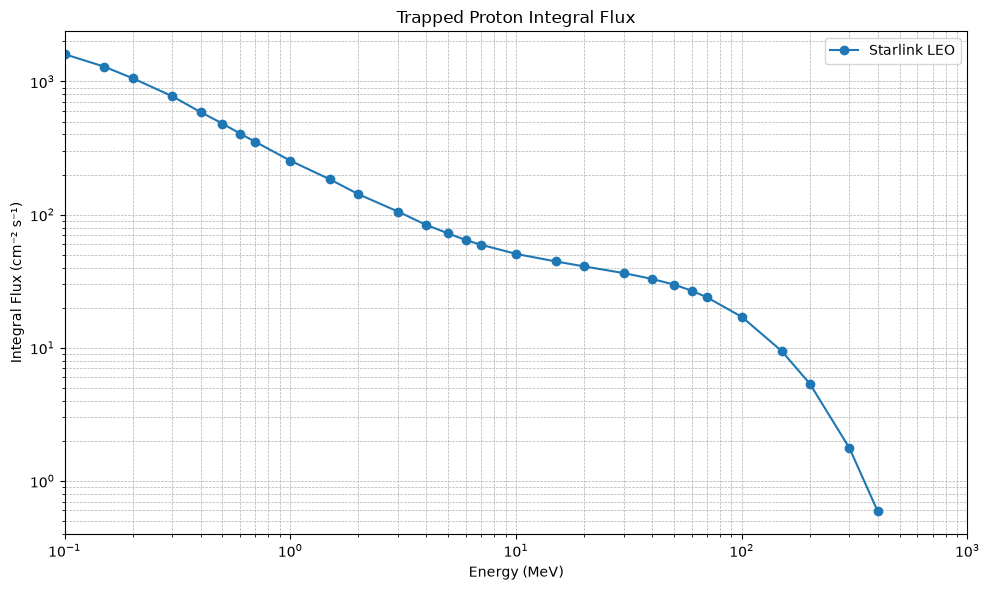

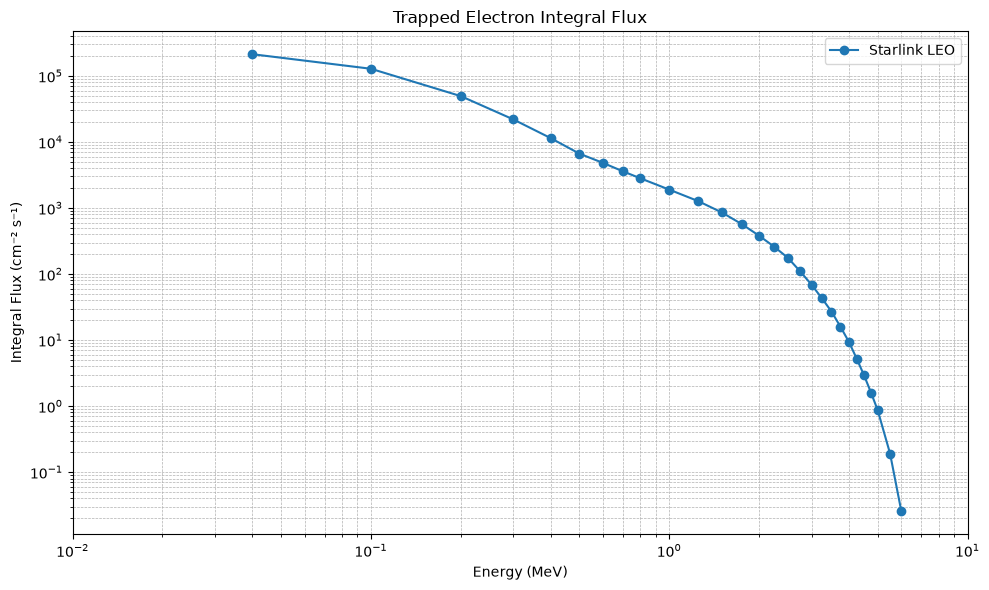

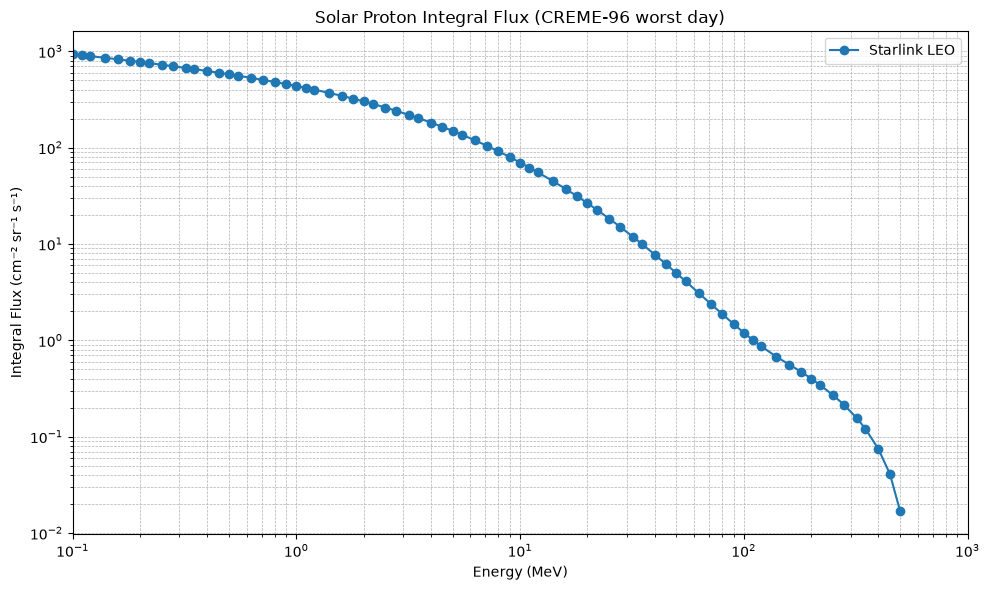

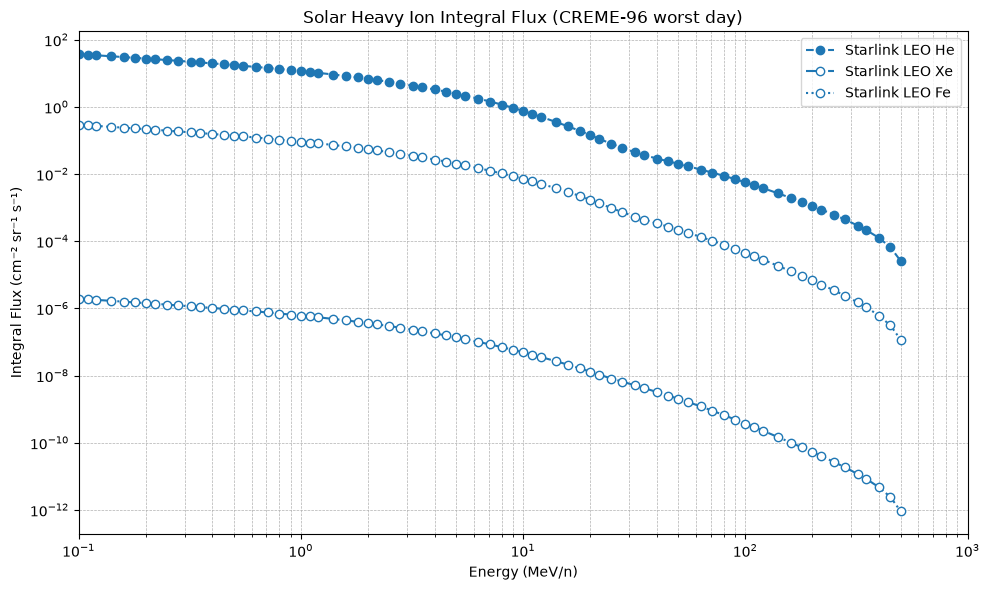

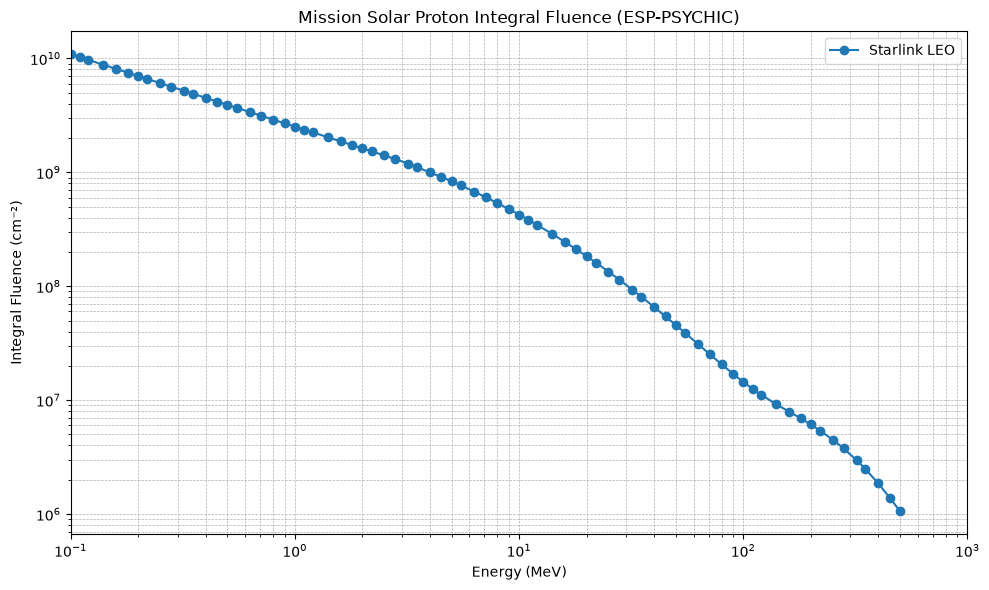

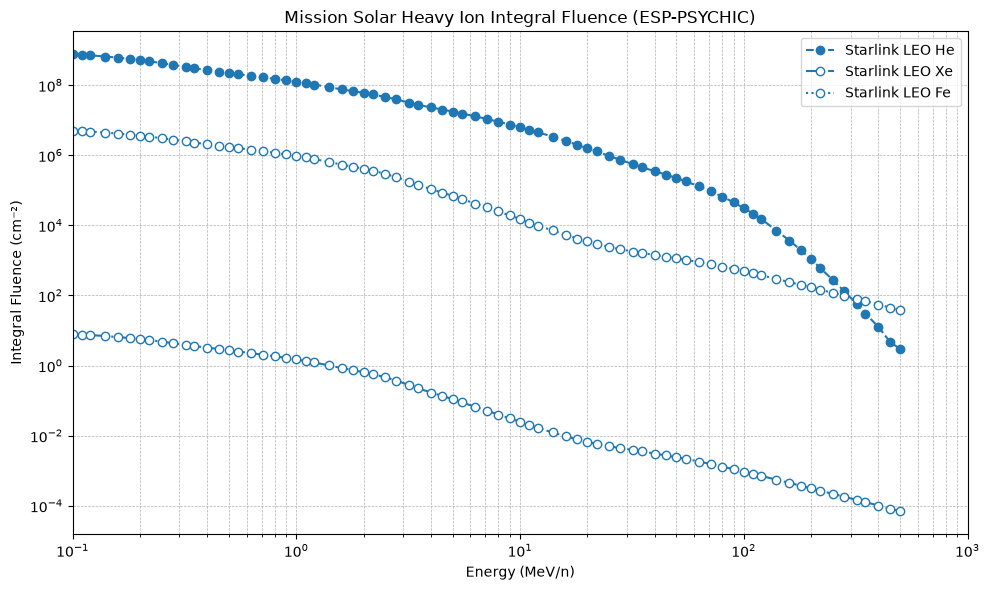

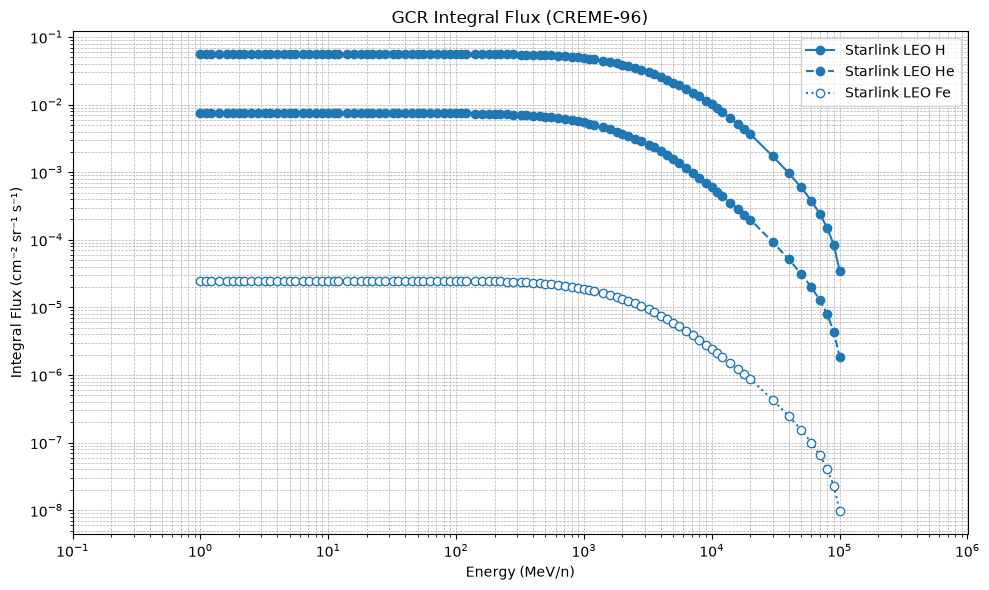

In [3]:
plot_all(missions, ions=["He", "Xe", "Fe"], gcr_ions=["H", "He", "Fe"], outdir=".")

## Individual plots
Any analysis can be plotted on its own with custom ions, limits, or title. Available analyses:

In [2]:
for k, a in ANALYSES.items():
    print(f"{k:24s} <- {a['file']:8s} file, block '{a['plt_hdr']}'")

trapped_protons          <- tri      file, block 'Orbit averaged flux'
trapped_electrons        <- tri      file, block 'Orbit averaged flux'
solar_protons_flux       <- sefflare file, block 'solar protons'
solar_ions_flux          <- sefflare file, block 'solar ions'
solar_protons_fluence    <- sef      file, block 'solar protons'
solar_ions_fluence       <- sef      file, block 'solar ions'
gcr_ions_flux            <- gcf      file, block 'ion spectrum (GCR)'


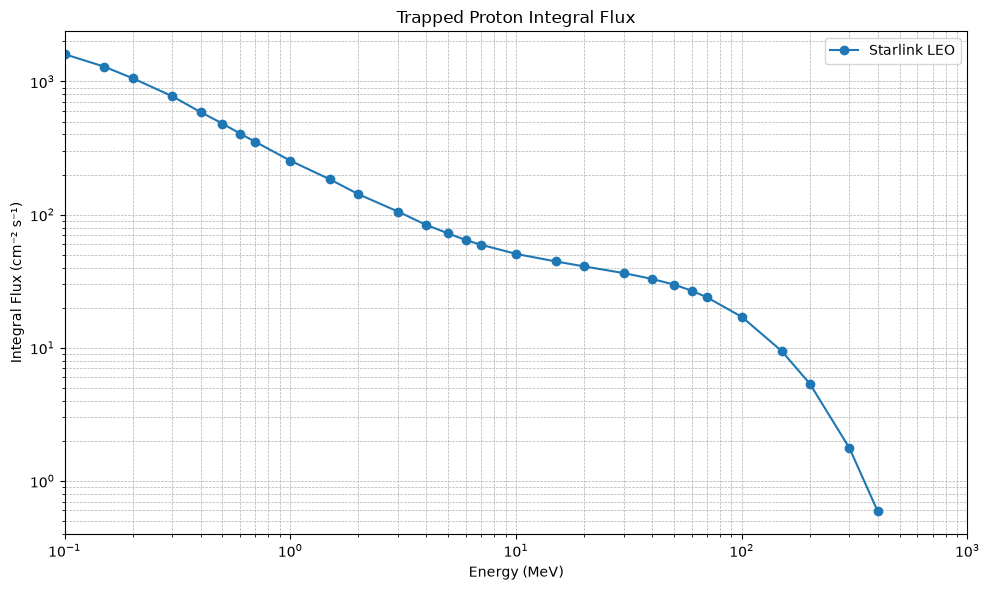

<Axes: title={'center': 'Trapped Proton Integral Flux'}, xlabel='Energy (MeV)', ylabel='Integral Flux (cm⁻² s⁻¹)'>

In [8]:
plot_spectra(missions, "trapped_protons", xlim=(0.1, 1e3), savefig="trapped_proton_integral_flux_loglog.png")

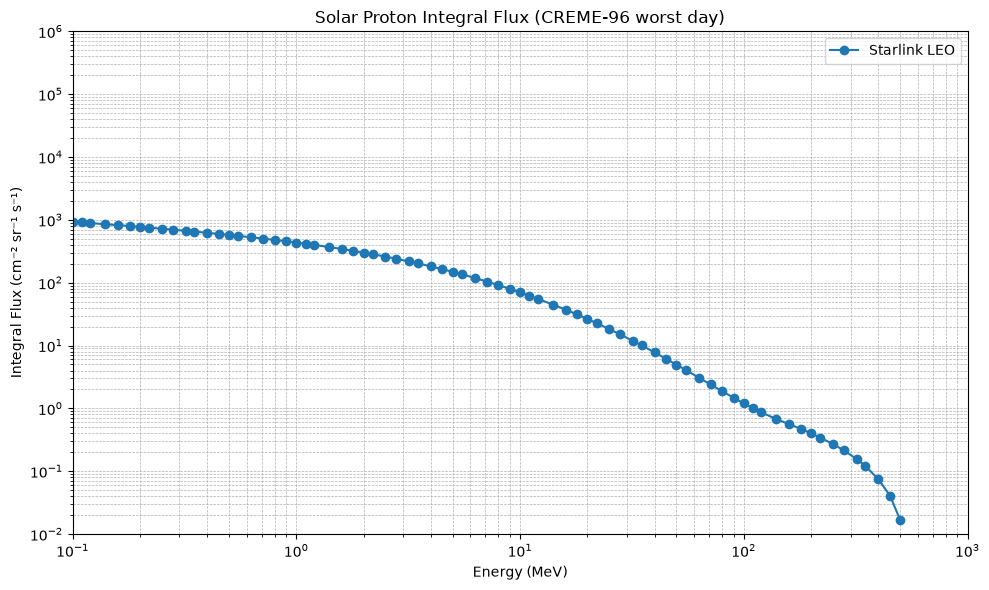

<Axes: title={'center': 'Solar Proton Integral Flux (CREME-96 worst day)'}, xlabel='Energy (MeV)', ylabel='Integral Flux (cm⁻² sr⁻¹ s⁻¹)'>

In [9]:
plot_spectra(missions, "solar_protons_flux", ylim=(1e-2, 1e6))

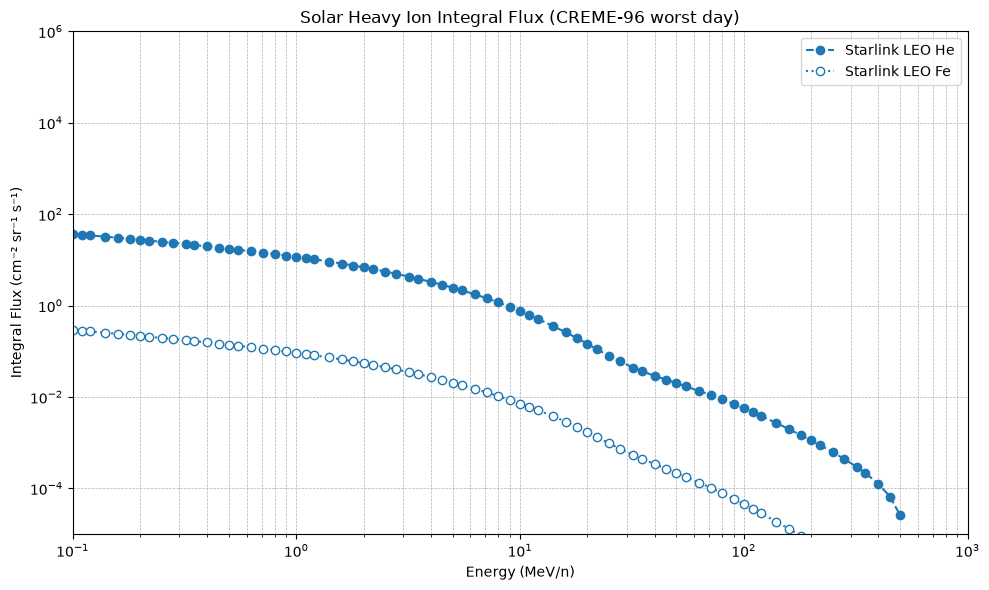

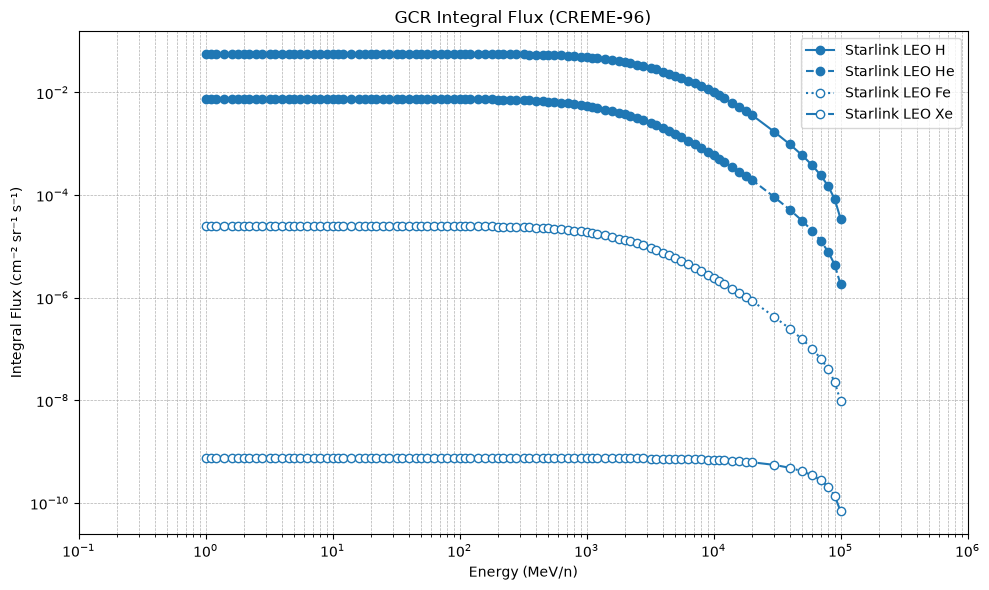

<Axes: title={'center': 'GCR Integral Flux (CREME-96)'}, xlabel='Energy (MeV/n)', ylabel='Integral Flux (cm⁻² sr⁻¹ s⁻¹)'>

In [10]:
# any element symbol works, e.g. Xe (Z=54) from the in-class activity
plot_spectra(missions, "solar_ions_flux", ions=["He", "Fe"], ylim=(1e-5, 1e6))
plot_spectra(missions, "gcr_ions_flux", ions=["H", "He", "Fe", "Xe"])

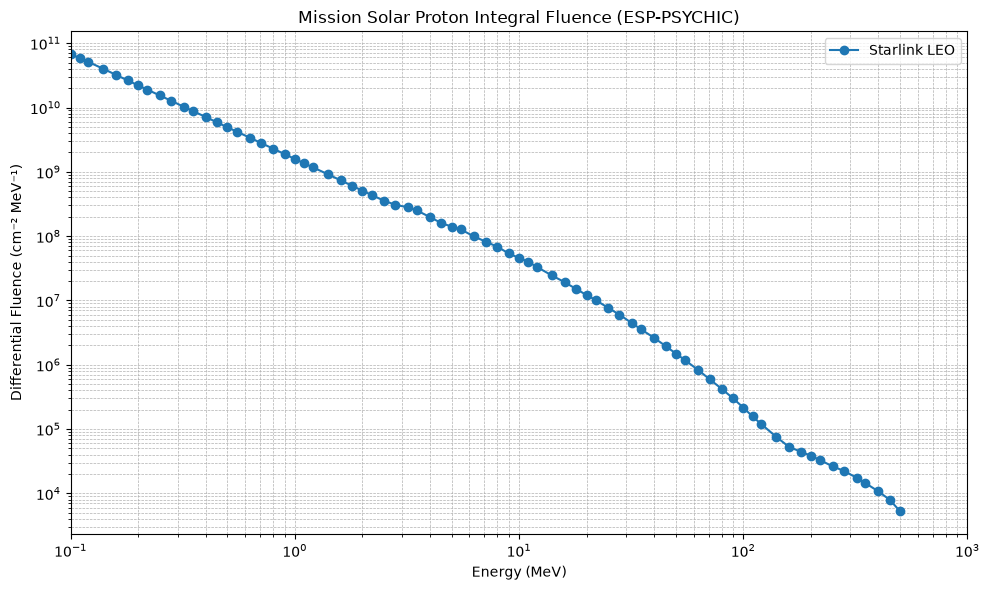

<Axes: title={'center': 'Mission Solar Proton Integral Fluence (ESP-PSYCHIC)'}, xlabel='Energy (MeV)', ylabel='Differential Fluence (cm⁻² MeV⁻¹)'>

In [11]:
# differential spectra are one keyword away
plot_spectra(missions, "solar_protons_fluence", kind="DFlux")

## Extending
* New mission: add one line to `MISSIONS`.
* New analysis (e.g. a different SPENVIS model or a differential-only block): add one entry to `ANALYSES` in `spenvis_tools.py` naming the file kind and a substring of the block's `PLT_HDR`.
* Any block from any file can also be reached directly: `missions[0].blocks("tri")` returns parsed `Block` objects with `.header`, `.species`, `.columns`, `.data`.